# Two-lane literature-retrieval pipeline (OpenAlex + Semantic Scholar)

This notebook implements **Phase A** and **Phase B** from `TWO_LANE_PIPELINE_IMPLEMENTATION_PLAN_FROM_REPORT.md`.

- **Phase A**: config surface, run artifacts under `runs/{run_id}/`, structured logging, and per-stage metrics.
- **Phase B**: LLM query planner that extracts **8–20 atomic bilingual facets** (EN+DE) with **strict JSON schema** output + caching.

**Ground rules for this test version**

- Prefer loud, detailed errors (so we can fix fast) over silent failure.
- Each code cell ends with a compact, easy-to-verify summary.
- When an OpenAI call happens, the cell prints token usage + estimated cost.


## Step 0 — Edit your chapter inputs

Edit the next cell, then run the notebook top-to-bottom.

What to look for (high level):

- **Good**: `runs/<run_id>/` created and contains `query_plan.json`, `logs.jsonl`, `metrics.json`.
- **Bad**: missing env vars (e.g. `OPENAI_API_KEY`) or schema errors from the query planner.


In [1]:
# -----------------------------
# USER INPUTS (edit this cell)
# -----------------------------

chapter_title = "Analyse: Ökonomische Befunde im (west-)römischen Reich und ihre Beziehungen zu Politik, Gesellschaft und Militär"

chapter_spec_text = """
Dieses Kapitel untersucht wirtschaftliche Faktoren im (west-)römischen Reich der Spätantike und stellt die Befunde so dar, 
 dass sie für die Erklärung des Zerfalls- bzw. Transformationsprozesses nutzbar sind. Es arbeitet wirtschaftliche Mechanismen, 
 Strukturveränderungen und Rahmenbedingungen heraus und ordnet sie als Befundbestand, wobei Befund, 
 Deutung und Reichweite der Schlussfolgerungen getrennt ausgewiesen werden. Anschließend wird geprüft, 
 in welcher Weise die ökonomischen Befunde mit politischen, 
 sozialen und militärischen Entwicklungen im (west-)römischen Reich verknüpft werden können: welche Beziehungen das Material stützt,
  wo Wechselwirkungen plausibel sind und wo Verbindungen unsicher bleiben. Das Kapitel endet mit einer zusammenfassenden Einordnung, 
  auf welcher Ebene wirtschaftliche Faktoren im Gesamtprozess erklärungsrelevant erscheinen.
""".strip()

# Keep this stable unless you intentionally want to invalidate caches.
pipeline_version = "two_lane_v1"

# Set True to ignore cached query_plan.json and re-call the LLM.
FORCE_REBUILD_QUERY_PLAN = False

# Set True to ignore cached provider query JSONs (Phase C) and re-call the LLM.
FORCE_REBUILD_PROVIDER_QUERIES = False


def _fmt_int(x) -> str:
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)


def _truncate(text: str, max_len: int = 180) -> str:
    s = str(text or "")
    return s if len(s) <= max_len else (s[: max_len - 1] + "…")


def print_section(title: str, width: int = 80, char: str = "=") -> None:
    line = char * width
    print(line)
    print(title)
    print(line)


def print_kv(d: dict, key_width: int = 26) -> None:
    for k, v in d.items():
        print(f"{str(k):<{key_width}} {v}")


print_section("User Inputs")
print_kv(
    {
        "chapter_title": _truncate(chapter_title),
        "chapter_spec_chars": _fmt_int(len(chapter_spec_text)),
        "pipeline_version": pipeline_version,
        "FORCE_REBUILD_QUERY_PLAN": FORCE_REBUILD_QUERY_PLAN,
        "FORCE_REBUILD_PROVIDER_QUERIES": FORCE_REBUILD_PROVIDER_QUERIES,
    }
)



User Inputs
chapter_title              Analyse: Ökonomische Befunde im (west-)römischen Reich und ihre Beziehungen zu Politik, Gesellschaft und Militär
chapter_spec_chars         877
pipeline_version           two_lane_v1
FORCE_REBUILD_QUERY_PLAN   False
FORCE_REBUILD_PROVIDER_QUERIES False


In [2]:
# Phase A.0 — Imports + env loading

import os
import sys
import json
import time
import hashlib
import logging
import re
from pathlib import Path
from datetime import datetime, timezone
from typing import Optional

import importlib.metadata as importlib_metadata


def _fmt_int(x) -> str:
    try:
        return f"{int(x):,}"
    except Exception:
        return str(x)


def _truncate(text: str, max_len: int = 120) -> str:
    s = str(text or "")
    return s if len(s) <= max_len else (s[: max_len - 1] + "…")


def print_section(title: str, width: int = 80, char: str = "=") -> None:
    line = char * width
    print(line)
    print(title)
    print(line)


def print_kv(d: dict, key_width: int = 26) -> None:
    for k, v in d.items():
        print(f"{str(k):<{key_width}} {v}")


def print_table(rows, *, columns, max_rows: int = 200, max_col_width: int = 60) -> None:
    rows = list(rows or [])
    if not rows:
        print("<empty>")
        return

    show = rows[:max_rows]
    cols = list(columns)

    def cell(row, col):
        v = row.get(col, "")
        if v is None:
            v = ""
        s = str(v)
        if len(s) > max_col_width:
            s = s[: max_col_width - 1] + "…"
        return s

    widths = {c: max(len(str(c)), max(len(cell(r, c)) for r in show)) for c in cols}
    header = " | ".join(f"{c:<{widths[c]}}" for c in cols)
    sep = "-+-".join("-" * widths[c] for c in cols)
    print(header)
    print(sep)
    for r in show:
        print(" | ".join(f"{cell(r, c):<{widths[c]}}" for c in cols))

    if len(rows) > max_rows:
        print(f"... ({_fmt_int(len(rows) - max_rows)} more rows)")


def _pkg_version(name: str) -> str:
    try:
        return importlib_metadata.version(name)
    except Exception:
        return "unknown"


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    markers = ["package.json", "pyproject.toml", ".git", "README.md"]
    for d in [start, *start.parents]:
        if any((d / m).exists() for m in markers):
            return d
    return start


def find_notebook_path(repo_root: Path, notebook_filename: str) -> Optional[Path]:
    matches = sorted(repo_root.rglob(notebook_filename))
    if not matches:
        return None
    if len(matches) == 1:
        return matches[0]

    for m in matches:
        if m.parent.name.lower() == "sources-v2":
            return m
    return matches[0]


REPO_ROOT = find_repo_root(Path.cwd())
NOTEBOOK_FILENAME = "sources_two_lane.ipynb"

NOTEBOOK_PATH = find_notebook_path(REPO_ROOT, NOTEBOOK_FILENAME)
if NOTEBOOK_PATH is not None:
    NOTEBOOK_DIR = NOTEBOOK_PATH.parent.resolve()
else:
    fallback = REPO_ROOT / "sources-v2"
    NOTEBOOK_DIR = (fallback if fallback.exists() else Path.cwd()).resolve()

try:
    from dotenv import load_dotenv
except Exception as e:
    raise ImportError(
        "Missing dependency: python-dotenv. Install with: pip install python-dotenv"
    ) from e

# Load repo-root .env first (override=True so local project config wins),
# then load fastapi/.env as a fallback (override=False).
loaded_env_files = []
root_env = REPO_ROOT / ".env"
if root_env.exists():
    load_dotenv(dotenv_path=root_env, override=True)
    loaded_env_files.append(str(root_env))

fastapi_env = REPO_ROOT / "fastapi" / ".env"
if fastapi_env.exists():
    load_dotenv(dotenv_path=fastapi_env, override=False)
    loaded_env_files.append(str(fastapi_env))

ENV_VARS = [
    "OPENAI_API_KEY",
    "OPENALEX_API_KEY",
    "OPENALEX_EMAIL",
    "OPENALEX_MAILTO",
    "SEMANTICSCHOLAR_API_KEY",
]

env_status = {k: ("<set>" if (os.getenv(k) or "").strip() else "<missing>") for k in ENV_VARS}
missing = [k for k, v in env_status.items() if v == "<missing>"]

print_section("Phase A.0 — Environment")
print_kv(
    {
        "cwd": Path.cwd(),
        "repo_root": REPO_ROOT,
        "notebook_dir": NOTEBOOK_DIR,
        "dotenv_loaded": loaded_env_files if loaded_env_files else "<none found>",
    },
    key_width=14,
)

print("\nVersions:")
print_kv(
    {
        "python": sys.version.split()[0],
        "openai": _pkg_version("openai"),
        "pydantic": _pkg_version("pydantic"),
        "python-dotenv": _pkg_version("python-dotenv"),
    },
    key_width=14,
)

print("\nEnv vars (presence only):")
print_table(
    [{"env_var": k, "status": env_status[k]} for k in ENV_VARS],
    columns=["env_var", "status"],
    max_rows=50,
)

if missing:
    print("\nMissing:")
    for k in missing:
        print(f"- {k}")


Phase A.0 — Environment
cwd            <projektverzeichnis>\sources-v2
repo_root      <projektverzeichnis>
notebook_dir   <projektverzeichnis>\sources-v2
dotenv_loaded  ['E:\\Datein\\Coding\\instantpaper\\.env', 'E:\\Datein\\Coding\\instantpaper\\fastapi\\.env']

Versions:
python         3.11.14
openai         2.14.0
pydantic       2.12.5
python-dotenv  1.2.1

Env vars (presence only):
env_var                 | status   
------------------------+----------
OPENAI_API_KEY          | <set>    
OPENALEX_API_KEY        | <set>    
OPENALEX_EMAIL          | <missing>
OPENALEX_MAILTO         | <missing>
SEMANTICSCHOLAR_API_KEY | <set>    

Missing:
- OPENALEX_EMAIL
- OPENALEX_MAILTO


In [3]:
# Phase A.1 — Config + run artifacts + structured logging helpers

from typing import Any, Dict, Optional
from contextlib import contextmanager

from pydantic import BaseModel, Field
from pydantic.config import ConfigDict


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).replace(microsecond=0).isoformat()


def stable_hash(*parts: str, length: int = 24) -> str:
    payload = "\n".join([(p or "").strip().replace("\r\n", "\n") for p in parts])
    return hashlib.sha256(payload.encode("utf-8")).hexdigest()[:length]


def compute_run_id(chapter_title: str, chapter_spec_text: str, pipeline_version: str) -> str:
    return stable_hash(pipeline_version, chapter_title, chapter_spec_text, length=24)


def ensure_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    return path


def _json_default(o: Any):
    if isinstance(o, Path):
        return str(o)
    raise TypeError(f"Object of type {type(o).__name__} is not JSON serializable")


def write_json(path: Path, obj: Any) -> None:
    ensure_dir(path.parent)
    tmp = path.with_suffix(path.suffix + ".tmp")
    tmp.write_text(
        json.dumps(obj, ensure_ascii=False, indent=2, default=_json_default) + "\n",
        encoding="utf-8",
    )
    tmp.replace(path)


def read_json(path: Path) -> Any:
    return json.loads(path.read_text(encoding="utf-8"))


def append_jsonl(path: Path, obj: Any) -> None:
    ensure_dir(path.parent)
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(obj, ensure_ascii=False, default=_json_default) + "\n")


class PipelineConfig(BaseModel):
    """Single config surface for the two-lane pipeline (test version)."""

    model_config = ConfigDict(extra="forbid")

    # Identity
    pipeline_version: str = "two_lane_v1"
    runs_root: Path

    # OpenAI (Phase B)
    openai_api_key: Optional[str] = Field(default=None, repr=False)
    openai_model_planner: str = "gpt-5-mini"
    openai_reasoning_effort: str = "minimal"
    openai_timeout_s: float = 43200.0
    # Output budget (Phase B planner)
    openai_max_output_tokens_planner: int = 100000
    # Providers (later phases)
    openalex_base_url: str = "https://api.openalex.org"
    openalex_api_key: Optional[str] = Field(default=None, repr=False)
    openalex_email: Optional[str] = None
    openalex_timeout_s: float = 60.0
    openalex_rps: float = 10.0

    semanticscholar_base_url: str = "https://api.semanticscholar.org/graph/v1"
    semanticscholar_api_key: Optional[str] = Field(default=None, repr=False)
    semanticscholar_timeout_s: float = 60.0
    semanticscholar_rps: float = 1.0

    # Hard caps
    max_queries_per_provider: int = 50

    # Embeddings (later phases)
    embedding_model: str = "text-embedding-3-small"
    embedding_batch_size: int = 256

    # Pruning (later phases)
    prune_n1: int = 600

    # S2 neighbor booster (later phases)
    s2_neighbor_seed_count: int = 5
    s2_recs_limit_per_seed: int = 300

    # Rerank (later phases)
    rerank_top_k_pre: int = 40
    rerank_concurrency: int = 20

    # Match aggregation weights (later phases)
    match_weight_best: float = 0.55
    match_weight_top_m: float = 0.25
    match_weight_cov: float = 0.20
    match_m: int = 3

    # Scoring constants (later phases)
    scoring_t: float = 0.30
    scoring_t_noabs: float = 0.35

    # Authority time stratification (later phases)
    authority_classic_year_max: int = 2004
    authority_recent_year_window: int = 8
    authority_bucket_quotas: Dict[str, int] = Field(
        default_factory=lambda: {"classic": 8, "mid": 6, "recent": 6}
    )

    @classmethod
    def from_env(
        cls,
        *,
        repo_root: Path,
        notebook_dir: Optional[Path],
        pipeline_version: str,
    ) -> "PipelineConfig":
        base_dir = (notebook_dir or repo_root).resolve()
        return cls(
            pipeline_version=pipeline_version,
            runs_root=base_dir / "runs",
            openai_api_key=(os.getenv("OPENAI_API_KEY") or "").strip() or None,
            openalex_api_key=(os.getenv("OPENALEX_API_KEY") or "").strip() or None,
            openalex_email=(
                (os.getenv("OPENALEX_EMAIL") or "").strip()
                or (os.getenv("OPENALEX_MAILTO") or "").strip()
                or None
            ),
            semanticscholar_api_key=(os.getenv("SEMANTICSCHOLAR_API_KEY") or "").strip() or None,
        )

    def masked(self) -> Dict[str, Any]:
        d = self.model_dump(mode="python")
        for k in ["openai_api_key", "openalex_api_key", "semanticscholar_api_key"]:
            d[k] = "<set>" if d.get(k) else "<missing>"
        d["runs_root"] = str(d["runs_root"])
        return d


class RunArtifacts(BaseModel):
    model_config = ConfigDict(extra="forbid")

    query_plan_json: Path
    openalex_queries_json: Path
    semanticscholar_queries_json: Path

    openalex_raw_jsonl: Path
    semanticscholar_raw_jsonl: Path
    semanticscholar_recommendations_jsonl: Path

    candidates_normalized_jsonl: Path
    candidates_normalized_csv: Path

    embeddings_manifest_jsonl: Path
    embeddings_manifest_csv: Path
    embeddings_vectors_dir: Path

    rerank_results_jsonl: Path
    output_json: Path

    logs_jsonl: Path
    run_log: Path
    metrics_json: Path


class RunContext(BaseModel):
    model_config = ConfigDict(extra="forbid")

    repo_root: Path
    run_id: str
    run_dir: Path
    artifacts: RunArtifacts

    def create_artifact_skeleton(self, *, overwrite: bool = False) -> None:
        ensure_dir(self.run_dir)
        ensure_dir(self.artifacts.embeddings_vectors_dir)

        jsonl_files = [
            self.artifacts.openalex_raw_jsonl,
            self.artifacts.semanticscholar_raw_jsonl,
            self.artifacts.semanticscholar_recommendations_jsonl,
            self.artifacts.candidates_normalized_jsonl,
            self.artifacts.embeddings_manifest_jsonl,
            self.artifacts.rerank_results_jsonl,
            self.artifacts.logs_jsonl,
        ]
        for p in jsonl_files:
            ensure_dir(p.parent)
            p.touch(exist_ok=True)

        ensure_dir(self.artifacts.run_log.parent)
        self.artifacts.run_log.touch(exist_ok=True)

        csv_files = [
            self.artifacts.candidates_normalized_csv,
            self.artifacts.embeddings_manifest_csv,
        ]
        for p in csv_files:
            ensure_dir(p.parent)
            if overwrite or not p.exists():
                p.write_text("", encoding="utf-8")

        if overwrite or not self.artifacts.metrics_json.exists():
            write_json(
                self.artifacts.metrics_json,
                {
                    "run_id": self.run_id,
                    "created_at_utc": utc_now_iso(),
                    "stages": {},
                },
            )


def setup_run_logger(run_ctx: RunContext, *, level: int = logging.INFO) -> logging.Logger:
    ensure_dir(run_ctx.run_dir)

    logger = logging.getLogger("two_lane")
    logger.setLevel(level)
    logger.propagate = False

    # Idempotent re-runs in notebooks.
    for h in list(logger.handlers):
        logger.removeHandler(h)

    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    sh = logging.StreamHandler(stream=sys.stdout)
    sh.setFormatter(fmt)
    fh = logging.FileHandler(run_ctx.artifacts.run_log, encoding="utf-8")
    fh.setFormatter(fmt)

    logger.addHandler(sh)
    logger.addHandler(fh)
    return logger


def log_event(run_ctx: RunContext, *, stage: str, event: str, **fields: Any) -> None:
    rec = {"ts": utc_now_iso(), "stage": stage, "event": event, **fields}
    append_jsonl(run_ctx.artifacts.logs_jsonl, rec)

    lg = logging.getLogger("two_lane")
    level = logging.INFO
    if "error" in fields or event.endswith("_error") or event.endswith("_failed"):
        level = logging.ERROR

    lg.log(
        level,
        json.dumps(
            {k: v for k, v in rec.items() if k != "ts"},
            ensure_ascii=False,
            default=_json_default,
        ),
    )


def load_metrics(run_ctx: RunContext) -> Dict[str, Any]:
    try:
        return read_json(run_ctx.artifacts.metrics_json)
    except Exception:
        return {"run_id": run_ctx.run_id, "created_at_utc": utc_now_iso(), "stages": {}}


def save_metrics(run_ctx: RunContext, metrics: Dict[str, Any]) -> None:
    metrics = dict(metrics)
    metrics["updated_at_utc"] = utc_now_iso()
    write_json(run_ctx.artifacts.metrics_json, metrics)


@contextmanager
def stage_timer(run_ctx: RunContext, stage: str):
    t0 = time.time()
    yield
    dt = time.time() - t0
    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault(stage, {})["last_duration_s"] = round(dt, 3)
    save_metrics(run_ctx, metrics)


In [4]:
# Phase A.2 — Create run directory + artifact skeleton (no provider calls)

# Build config from env (runs are stored next to the notebook)
cfg = PipelineConfig.from_env(
    repo_root=REPO_ROOT,
    notebook_dir=NOTEBOOK_DIR,
    pipeline_version=pipeline_version,
)

# Compute run_id from chapter inputs
run_id = compute_run_id(chapter_title, chapter_spec_text, cfg.pipeline_version)
run_dir = cfg.runs_root / run_id

artifacts = RunArtifacts(
    query_plan_json=run_dir / "query_plan.json",
    openalex_queries_json=run_dir / "openalex_queries.json",
    semanticscholar_queries_json=run_dir / "semanticscholar_queries.json",
    openalex_raw_jsonl=run_dir / "openalex_raw.jsonl",
    semanticscholar_raw_jsonl=run_dir / "semanticscholar_raw.jsonl",
    semanticscholar_recommendations_jsonl=run_dir / "semanticscholar_recommendations.jsonl",
    candidates_normalized_jsonl=run_dir / "candidates_normalized.jsonl",
    candidates_normalized_csv=run_dir / "candidates_normalized.csv",
    embeddings_manifest_jsonl=run_dir / "embeddings_manifest.jsonl",
    embeddings_manifest_csv=run_dir / "embeddings_manifest.csv",
    embeddings_vectors_dir=run_dir / "embeddings_vectors",
    rerank_results_jsonl=run_dir / "rerank_results.jsonl",
    output_json=run_dir / "output.json",
    logs_jsonl=run_dir / "logs.jsonl",
    run_log=run_dir / "run.log",
    metrics_json=run_dir / "metrics.json",
)

run_ctx = RunContext(repo_root=REPO_ROOT, run_id=run_id, run_dir=run_dir, artifacts=artifacts)

with stage_timer(run_ctx, "phase_a"):
    run_ctx.create_artifact_skeleton(overwrite=False)
    logger = setup_run_logger(run_ctx)
    log_event(run_ctx, stage="phase_a", event="run_initialized", run_id=run_id, run_dir=str(run_dir))

    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault("phase_a", {})["initialized_at_utc"] = utc_now_iso()
    save_metrics(run_ctx, metrics)

# Show current run folder contents
files = sorted([p.relative_to(run_dir) for p in run_dir.rglob("*") if p.is_file()])

print_section("Phase A.2 — Run Initialized")
print_kv({"run_id": run_id, "run_dir": run_dir, "runs_root": cfg.runs_root}, key_width=10)

print("\nConfig (masked):")
print_kv(cfg.masked(), key_width=28)

print("\nFiles currently in run_dir:")
print_table([{"file": str(f)} for f in files], columns=["file"], max_rows=200)


2026-02-12 00:45:31,631 | INFO | {"stage": "phase_a", "event": "run_initialized", "run_id": "d5a67f10a618dec647502773", "run_dir": "E:\\Datein\\Coding\\instantpaper\\sources-v2\\runs\\d5a67f10a618dec647502773"}
Phase A.2 — Run Initialized
run_id     d5a67f10a618dec647502773
run_dir    <projektverzeichnis>\sources-v2\runs\d5a67f10a618dec647502773
runs_root  <projektverzeichnis>\sources-v2\runs

Config (masked):
pipeline_version             two_lane_v1
runs_root                    <projektverzeichnis>\sources-v2\runs
openai_api_key               <set>
openai_model_planner         gpt-5-mini
openai_reasoning_effort      minimal
openai_timeout_s             43200.0
openai_max_output_tokens_planner 100000
openalex_base_url            https://api.openalex.org
openalex_api_key             <set>
openalex_email               None
openalex_timeout_s           60.0
openalex_rps                 10.0
semanticscholar_base_url     https://api.semanticscholar.org/graph/v1
semanticscholar_api_key      

In [5]:
# Phase B.1 — Data models (strict) for the Query Planner output

from typing import List


class BilingualTerms(BaseModel):
    model_config = ConfigDict(extra="forbid")

    en: List[str] = Field(default_factory=list)
    de: List[str] = Field(default_factory=list)


class Facet(BaseModel):
    model_config = ConfigDict(extra="forbid")

    facet_id: str
    facet_label_en: str
    facet_label_de: str
    facet_type: str
    importance_weight: int = Field(ge=1, le=5)
    text_en: str
    text_de: str
    canonical_terms: BilingualTerms
    neighbor_terms: BilingualTerms
    exclusion_terms: BilingualTerms


class QueryPlan(BaseModel):
    model_config = ConfigDict(extra="forbid")

    topic_summary_en: str
    topic_summary_de: str
    facets: List[Facet]
    global_canonical_terms: BilingualTerms
    global_exclusions: BilingualTerms


class ChapterInput(BaseModel):
    model_config = ConfigDict(extra="forbid")

    chapter_title: str
    chapter_spec_text: str
    pipeline_version: str

    def compute_run_id(self) -> str:
        return compute_run_id(self.chapter_title, self.chapter_spec_text, self.pipeline_version)


In [6]:
# Phase B.2 — OpenAI helpers: strict JSON schema outputs + token/cost tracking

import json
import time
import re
from pathlib import Path
from typing import Any, Dict, Optional, Tuple

from openai import OpenAI


# Model prices (USD per *1M tokens*) — verify periodically.
# NOTE: cached token pricing can differ; set the correct values for your account.
MODEL_PRICES_USD_PER_1M: Dict[str, Dict[str, float]] = {
    "gpt-5.2": {"input": 1.75, "cached": 1.75, "output": 14.00},
    "gpt-5-mini": {"input": 0.25, "cached": 0.25, "output": 2.00},
    "gpt-5-nano": {"input": 0.05, "cached": 0.05, "output": 0.40},
}


def resolve_pricing_key(model_name: str) -> Optional[str]:
    model_lower = (model_name or "").lower()
    normalized = {k.lower(): k for k in MODEL_PRICES_USD_PER_1M}

    if model_lower in normalized:
        return normalized[model_lower]

    # Strip trailing release suffix: -YYYY-MM-DD
    date_stripped = re.sub(r"-20\d{2}-\d{2}-\d{2}$", "", model_lower)
    if date_stripped in normalized:
        return normalized[date_stripped]

    # Prefix match: gpt-5.2-foo
    for k_lower, original in normalized.items():
        if model_lower.startswith(k_lower + "-"):
            return original

    return None


def extract_usage(response) -> Dict[str, int]:
    usage = getattr(response, "usage", None)
    if usage is None:
        return {
            "input_tokens": 0,
            "output_tokens": 0,
            "reasoning_tokens": 0,
            "cached_input_tokens": 0,
        }

    input_tokens = int(getattr(usage, "input_tokens", None) or getattr(usage, "prompt_tokens", None) or 0)
    output_tokens = int(getattr(usage, "output_tokens", None) or getattr(usage, "completion_tokens", None) or 0)

    cached_input_tokens = 0
    input_details = getattr(usage, "input_tokens_details", None) or getattr(usage, "prompt_tokens_details", None)
    if input_details is not None:
        cached_input_tokens = int(getattr(input_details, "cached_tokens", 0) or 0)

    reasoning_tokens = 0
    out_details = getattr(usage, "output_tokens_details", None) or getattr(usage, "completion_tokens_details", None)
    if out_details is not None:
        reasoning_tokens = int(getattr(out_details, "reasoning_tokens", 0) or 0)

    return {
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "reasoning_tokens": reasoning_tokens,
        "cached_input_tokens": cached_input_tokens,
    }


def estimate_cost_usd(
    *,
    model_used: str,
    input_tokens: int,
    cached_input_tokens: int,
    output_tokens: int,
) -> Dict[str, Any]:
    key = resolve_pricing_key(model_used)
    if key is None:
        return {
            "pricing_key": None,
            "input_cost_usd": 0.0,
            "cached_input_cost_usd": 0.0,
            "output_cost_usd": 0.0,
            "total_cost_usd": 0.0,
            "note": f"No pricing found for model={model_used!r}; update MODEL_PRICES_USD_PER_1M.",
        }

    prices = MODEL_PRICES_USD_PER_1M[key]
    in_price = float(prices.get("input", 0.0) or 0.0)
    cached_price = float(prices.get("cached", in_price) or in_price)
    out_price = float(prices.get("output", 0.0) or 0.0)

    cached_input_tokens = max(0, min(int(cached_input_tokens or 0), int(input_tokens or 0)))
    billable_input_tokens = max(int(input_tokens or 0) - cached_input_tokens, 0)

    input_cost = (billable_input_tokens / 1_000_000) * in_price
    cached_cost = (cached_input_tokens / 1_000_000) * cached_price
    output_cost = (int(output_tokens or 0) / 1_000_000) * out_price

    return {
        "pricing_key": key,
        "price_per_million": {"input": in_price, "cached": cached_price, "output": out_price},
        "billable_input_tokens": billable_input_tokens,
        "input_cost_usd": float(input_cost),
        "cached_input_cost_usd": float(cached_cost),
        "output_cost_usd": float(output_cost),
        "total_cost_usd": float(input_cost + cached_cost + output_cost),
        "note": "output_tokens already includes reasoning_tokens; reasoning_tokens is shown for diagnostics only.",
    }


def _response_to_jsonable(response) -> Dict[str, Any]:
    if response is None:
        return {}

    if hasattr(response, "model_dump"):
        try:
            return response.model_dump(mode="json")
        except TypeError:
            return response.model_dump()
        except Exception:
            pass

    if hasattr(response, "to_dict"):
        try:
            return response.to_dict()
        except Exception:
            pass

    return {"repr": repr(response)}


def extract_output_text_or_refusal(response) -> Tuple[str, Optional[str]]:
    text = getattr(response, "output_text", None)
    if isinstance(text, str) and text.strip():
        return text, None

    parts = []
    refusal = None

    output_items = getattr(response, "output", None) or []
    for item in output_items:
        item_type = item.get("type") if isinstance(item, dict) else getattr(item, "type", None)
        if item_type != "message":
            continue

        content_items = item.get("content") if isinstance(item, dict) else getattr(item, "content", None)
        for c in content_items or []:
            c_type = c.get("type") if isinstance(c, dict) else getattr(c, "type", None)
            if c_type == "output_text":
                t = c.get("text") if isinstance(c, dict) else getattr(c, "text", None)
                if t:
                    parts.append(str(t))
            elif c_type == "refusal":
                r = c.get("refusal") if isinstance(c, dict) else getattr(c, "refusal", None)
                if r:
                    refusal = (str(refusal) + "\n" + str(r)) if refusal else str(r)

    joined = "\n".join([p for p in parts if str(p).strip()])
    return joined, refusal


def _step_down_reasoning_effort(effort: str) -> str:
    order = ["high", "medium", "low", "minimal"]
    e = (effort or "").strip().lower()
    if e not in order:
        return effort
    idx = order.index(e)
    return order[min(idx + 1, len(order) - 1)]


def _parse_max_output_tokens_limit(msg: str) -> Optional[int]:
    if not msg:
        return None

    patterns = [
        r"max_output_tokens\s*must\s*be\s*<=\s*(\d+)",
        r"max_output_tokens\s*must\s*be\s*less\s*than\s*or\s*equal\s*to\s*(\d+)",
        r"max_output_tokens.*?maximum\s*(?:is|of)\s*(\d+)",
        r"maximum\s*max_output_tokens\s*(?:is|of)\s*(\d+)",
    ]
    for pat in patterns:
        m = re.search(pat, msg, flags=re.IGNORECASE)
        if m:
            try:
                return int(m.group(1))
            except Exception:
                return None

    return None


def openai_json_schema_call(
    *,
    api_key: str,
    model: str,
    system_prompt: str,
    user_prompt: str,
    schema_name: str,
    schema: Dict[str, Any],
    reasoning_effort: str = "high",
    max_output_tokens: int = 2000,
    timeout_s: float = 120.0,
    debug_dir: Optional[Path] = None,
    debug_prefix: str = "openai",
) -> Tuple[Dict[str, Any], Dict[str, Any]]:
    """Minimal helper: build prompt, send request, parse strict JSON, return usage + cost.

    Uses `background=True` + polling to avoid long-lived HTTP read timeouts.
    """

    if not api_key:
        raise ValueError("OPENAI_API_KEY is missing. Set it in your repo .env (or environment) before Phase B.")

    client = OpenAI(api_key=api_key)

    max_output_tokens = max(256, int(max_output_tokens or 0))
    overall_timeout_s = float(timeout_s or 120.0)

    http_timeout_create_s = float(min(max(30.0, overall_timeout_s), 600.0))
    http_timeout_poll_s = float(min(60.0, http_timeout_create_s))

    def _dump(*, response=None, raw_text=None, refusal=None, exc=None, call_meta=None):
        if debug_dir is None:
            return
        try:
            ensure_dir(debug_dir)
            (debug_dir / f"{debug_prefix}.system_prompt.txt").write_text(system_prompt, encoding="utf-8")
            (debug_dir / f"{debug_prefix}.user_prompt.txt").write_text(user_prompt, encoding="utf-8")
            if call_meta is not None:
                write_json(debug_dir / f"{debug_prefix}.call_meta.json", call_meta)
            if response is not None:
                write_json(debug_dir / f"{debug_prefix}.response.json", _response_to_jsonable(response))
            if raw_text is not None:
                (debug_dir / f"{debug_prefix}.output_text.txt").write_text(raw_text or "", encoding="utf-8")
            if refusal:
                (debug_dir / f"{debug_prefix}.refusal.txt").write_text(str(refusal), encoding="utf-8")
            if exc is not None:
                write_json(debug_dir / f"{debug_prefix}.exception.json", {"error": str(exc), "type": type(exc).__name__})
        except Exception:
            pass

    t0 = time.time()
    try:
        response = client.responses.create(
            model=model,
            input=[
                {"role": "system", "content": [{"type": "input_text", "text": system_prompt}]},
                {"role": "user", "content": [{"type": "input_text", "text": user_prompt}]},
            ],
            reasoning={"effort": reasoning_effort},
            max_output_tokens=max_output_tokens,
            text={
                "format": {
                    "type": "json_schema",
                    "name": schema_name,
                    "schema": schema,
                    "strict": True,
                }
            },
            background=True,
            timeout=http_timeout_create_s,
        )

        response_id = getattr(response, "id", None)
        terminal_statuses = {"completed", "incomplete", "failed", "cancelled", "canceled"}

        poll_t0 = time.time()
        poll_sleep_s = 1.0
        while getattr(response, "status", None) not in terminal_statuses:
            if (time.time() - poll_t0) > overall_timeout_s:
                raise TimeoutError(
                    f"OpenAI background response timed out after {int(overall_timeout_s)}s "
                    f"(last_status={getattr(response, 'status', None)!r}, response_id={response_id!r})."
                )
            time.sleep(poll_sleep_s)
            poll_sleep_s = min(poll_sleep_s * 1.5, 10.0)
            response = client.responses.retrieve(response_id, timeout=http_timeout_poll_s)

        dt = time.time() - t0

        model_used = getattr(response, "model", None) or model
        status = getattr(response, "status", None)
        incomplete_details = getattr(response, "incomplete_details", None)
        incomplete_reason = (
            incomplete_details.get("reason")
            if isinstance(incomplete_details, dict)
            else getattr(incomplete_details, "reason", None)
        )

        usage = extract_usage(response)
        raw_text, refusal = extract_output_text_or_refusal(response)

        call_meta = {
            "model_requested": model,
            "model_used": model_used,
            "response_id": response_id,
            "status": status,
            "incomplete_reason": incomplete_reason,
            "latency_s": round(dt, 3),
            "usage": usage,
            "reasoning_effort": reasoning_effort,
            "max_output_tokens": max_output_tokens,
            "timeout_s": overall_timeout_s,
            "http_timeout_create_s": http_timeout_create_s,
            "http_timeout_poll_s": http_timeout_poll_s,
        }

        _dump(response=response, raw_text=raw_text, refusal=refusal, call_meta=call_meta)

        if refusal and not (raw_text or "").strip():
            raise ValueError(f"OpenAI refused the request: {refusal}")

        if not (raw_text or "").strip():
            raise ValueError(
                "OpenAI response had no output_text. "
                f"status={status!r} incomplete_reason={incomplete_reason!r} "
                f"response_id={response_id!r} usage={usage}."
            )

        obj = json.loads(raw_text)

        cost = estimate_cost_usd(
            model_used=model_used,
            input_tokens=usage.get("input_tokens", 0),
            cached_input_tokens=usage.get("cached_input_tokens", 0),
            output_tokens=usage.get("output_tokens", 0),
        )

        meta = {
            "model_requested": model,
            "model_used": model_used,
            "response_id": response_id,
            "latency_s": round(dt, 3),
            "usage": usage,
            "cost_estimate": cost,
            "status": status,
            "incomplete_reason": incomplete_reason,
        }
        return obj, meta

    except Exception as e:
        _dump(exc=e)
        raise


    raise RuntimeError("openai_json_schema_call: exhausted attempts without returning")



In [7]:
# Phase B.3 — LLM Query Planner (facet extraction; atomic bilingual facets)

import traceback
from typing import Any, Dict, Tuple


QUERY_PLAN_JSON_SCHEMA = {
    "type": "object",
    "additionalProperties": False,
    "required": [
        "topic_summary_en",
        "topic_summary_de",
        "facets",
        "global_canonical_terms",
        "global_exclusions",
    ],
    "properties": {
        "topic_summary_en": {"type": "string"},
        "topic_summary_de": {"type": "string"},
        "global_canonical_terms": {
            "type": "object",
            "additionalProperties": False,
            "required": ["en", "de"],
            "properties": {
                "en": {"type": "array", "items": {"type": "string"}},
                "de": {"type": "array", "items": {"type": "string"}},
            },
        },
        "global_exclusions": {
            "type": "object",
            "additionalProperties": False,
            "required": ["en", "de"],
            "properties": {
                "en": {"type": "array", "items": {"type": "string"}},
                "de": {"type": "array", "items": {"type": "string"}},
            },
        },
        "facets": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "required": [
                    "facet_id",
                    "facet_label_en",
                    "facet_label_de",
                    "facet_type",
                    "importance_weight",
                    "text_en",
                    "text_de",
                    "canonical_terms",
                    "neighbor_terms",
                    "exclusion_terms",
                ],
                "properties": {
                    "facet_id": {"type": "string"},
                    "facet_label_en": {"type": "string"},
                    "facet_label_de": {"type": "string"},
                    "facet_type": {"type": "string"},
                    "importance_weight": {"type": "integer", "minimum": 1, "maximum": 5},
                    "text_en": {"type": "string"},
                    "text_de": {"type": "string"},
                    "canonical_terms": {
                        "type": "object",
                        "additionalProperties": False,
                        "required": ["en", "de"],
                        "properties": {
                            "en": {"type": "array", "items": {"type": "string"}},
                            "de": {"type": "array", "items": {"type": "string"}},
                        },
                    },
                    "neighbor_terms": {
                        "type": "object",
                        "additionalProperties": False,
                        "required": ["en", "de"],
                        "properties": {
                            "en": {"type": "array", "items": {"type": "string"}},
                            "de": {"type": "array", "items": {"type": "string"}},
                        },
                    },
                    "exclusion_terms": {
                        "type": "object",
                        "additionalProperties": False,
                        "required": ["en", "de"],
                        "properties": {
                            "en": {"type": "array", "items": {"type": "string"}},
                            "de": {"type": "array", "items": {"type": "string"}},
                        },
                    },
                },
            },
        },
    },
}


PLANNER_SYSTEM_PROMPT = """You are a scientific literature search planner. Your job is to convert a chapter title and a ~200-word chapter specification into:
(1) a short topic summary,
(2) 8–20 atomic facets (requirements) with importance weights,
(3) bilingual (EN+DE) canonical terms, neighbor terms, and exclusion terms.
Do NOT name specific papers, authors, or venues. Do NOT invent citations. Be deterministic and consistent.
"""

PLANNER_USER_PROMPT_TEMPLATE = """CHAPTER_TITLE:
{{chapter_title}}

CHAPTER_SPEC (instructions):
{{chapter_spec_text}}

TASK:
Create a QueryPlan JSON object with:
- topic_summary_en: 2–3 sentences
- topic_summary_de: 2–3 sentences (natural German)
- facets: 8–20 items. Each facet must be ATOMIC (one requirement/aspect).
  For each facet:
    - facet_id: short stable id (lower_snake_case, 3–6 words)
    - facet_label_en: <=8 words
    - facet_label_de: <=8 words
    - importance_weight: integer 1..5
      * 5 = explicitly required / central objective
      * 4 = important supporting requirement
      * 3 = useful context or common subtopic
      * 2 = peripheral
      * 1 = optional/rare
    - text_en: 1–2 sentences describing the facet
    - text_de: 1–2 sentences describing the facet (natural German)
    - canonical_terms:
        en: 6–18 terms/phrases (include synonyms, abbreviations)
        de: 6–18 terms/phrases (include German equivalents + common English loan terms if used in German literature)
    - neighbor_terms:
        en: 4–12 related/adjacent terms (broader/narrower/nearby topics)
        de: 4–12 related/adjacent terms
    - exclusion_terms:
        en: 0–8 terms to avoid wrong senses
        de: 0–8 terms to avoid wrong senses

Also output:
- global_canonical_terms.en/de (10–25)
- global_exclusions.en/de (0–15)

WEIGHT CALIBRATION RULES (dynamic, no fixed counts):
1) First, privately assign each facet an "importance_points" score in 0..100 based on the chapter spec:
   - 90–100: explicitly required and central to writing the chapter
   - 70–89: major supporting content likely expected in the chapter
   - 40–69: useful background/context or common subtopic
   - 10–39: peripheral / optional
   - 0–9: rare edge case
   (Do NOT output importance_points; only use it to calibrate weights.)
2) Convert importance_points to importance_weight using relative calibration:
   - Weight 5 = only facets that are truly top-tier (typically the top ~15–25% by importance_points).
   - Weight 4 = next tier of important facets (typically the next ~25–40%).
   - Weight 3 = the broad middle of useful facets.
   - Weight 2 = peripheral.
   - Weight 1 = optional/rare.
3) Self-check and adjust to ensure prioritization works:
   - Do NOT allow most facets to be weight 5. If too many facets got weight 5, downgrade the least central ones to 4.
   - Ensure at least 3 distinct weight levels appear across all facets (so ranking can prioritize).
   - Every weight-5 facet must be either core_requirement, methodology, or synthesis (never neighbor).
4) facet_type guidance:
   - core_requirement: content the chapter must cover to satisfy the spec
   - supporting_requirement: important but not the central core
   - methodology: evidence quality, methods, limits, measurement, data types
   - synthesis: interpretation, mechanisms, causal links, levels of explanation
   - neighbor: adjacent topics useful for recall and completeness (keep weights lower unless spec demands them)

QUALITY RULES:
- Cover all explicit instructions in CHAPTER_SPEC via facets (no big gaps).
- Add 2–4 neighbor facets that are not explicitly stated but are commonly necessary.
- Keep facets minimally overlapping; avoid combining multiple big ideas in one facet.
- Prefer technical anchors that work as search terms (entities, methods, institutional terms, standard constructs).
- If a term is ambiguous, add exclusion_terms for disambiguation rather than vague phrasing.
- Do not use citations or names of specific works.


OUTPUT:
Return ONLY valid JSON matching the schema described. No extra text.
"""


def planner_user_prompt(chapter_input: ChapterInput) -> str:
    s = PLANNER_USER_PROMPT_TEMPLATE
    s = s.replace("{{chapter_title}}", chapter_input.chapter_title.strip())
    s = s.replace("{{chapter_spec_text}}", chapter_input.chapter_spec_text.strip())
    return s


def diagnose_query_plan(plan: QueryPlan) -> Dict[str, Any]:
    issues = []

    n_facets = len(plan.facets)
    if n_facets < 8 or n_facets > 20:
        issues.append(f"Facet count is {n_facets} (expected 8–20).")

    ids = [f.facet_id for f in plan.facets]
    dup_ids = sorted({x for x in ids if ids.count(x) > 1})
    if dup_ids:
        issues.append(f"Duplicate facet_id(s): {dup_ids}")

    bad_weights = [f.facet_id for f in plan.facets if not (1 <= f.importance_weight <= 5)]
    if bad_weights:
        issues.append(f"Facets with invalid importance_weight: {bad_weights}")

    # Very rough overlap heuristic: identical canonical term sets.
    canon_sets = {}
    overlaps = []
    for f in plan.facets:
        key = (
            tuple(sorted({t.strip().lower() for t in f.canonical_terms.en if t.strip()})),
            tuple(sorted({t.strip().lower() for t in f.canonical_terms.de if t.strip()})),
        )
        if key in canon_sets and key != ((), ()):
            overlaps.append((canon_sets[key], f.facet_id))
        else:
            canon_sets[key] = f.facet_id

    if overlaps:
        issues.append(f"Potential duplicate facets (identical canonical_terms): {overlaps[:5]}")

    return {"facet_count": n_facets, "issues": issues}


def _is_placeholder_cache(obj: Any) -> bool:
    if not isinstance(obj, dict):
        return False
    meta = obj.get("_meta")
    return isinstance(meta, dict) and meta.get("placeholder") is True


def plan_queries_llm(
    chapter_input: ChapterInput,
    *,
    config: PipelineConfig,
    run_ctx: RunContext,
    force_rebuild: bool = False,
) -> Tuple[QueryPlan, Dict[str, Any]]:
    stage = "phase_b_query_planner"
    cache_path = run_ctx.artifacts.query_plan_json

    if cache_path.exists() and not force_rebuild:
        try:
            cached_obj = read_json(cache_path)
            if _is_placeholder_cache(cached_obj):
                log_event(run_ctx, stage=stage, event="cache_placeholder_ignored", path=str(cache_path))
            else:
                plan = QueryPlan.model_validate(cached_obj)
                meta = {
                    "cache_hit": True,
                    "usage": {
                        "input_tokens": 0,
                        "cached_input_tokens": 0,
                        "output_tokens": 0,
                        "reasoning_tokens": 0,
                    },
                    "cost_estimate": {"total_cost_usd": 0.0},
                    "diagnostics": diagnose_query_plan(plan),
                }
                log_event(run_ctx, stage=stage, event="cache_hit", path=str(cache_path))
                return plan, meta
        except Exception as e:
            err = str(e)
            err_short = err if len(err) <= 800 else (err[:800] + "…")
            write_json(
                run_ctx.run_dir / "query_plan.cache_invalid.json",
                {"ts": utc_now_iso(), "path": str(cache_path), "error": err},
            )
            log_event(run_ctx, stage=stage, event="cache_invalid", path=str(cache_path), error=err_short)

    user_prompt = planner_user_prompt(chapter_input)

    with stage_timer(run_ctx, stage):
        try:
            obj, meta = openai_json_schema_call(
                api_key=config.openai_api_key or "",
                model=config.openai_model_planner,
                system_prompt=PLANNER_SYSTEM_PROMPT,
                user_prompt=user_prompt,
                schema_name="query_plan",
                schema=QUERY_PLAN_JSON_SCHEMA,
                reasoning_effort=config.openai_reasoning_effort,
                max_output_tokens=getattr(config, "openai_max_output_tokens_planner", 6000),
                timeout_s=config.openai_timeout_s,
                debug_dir=run_ctx.run_dir,
                debug_prefix="query_plan",
            )
        except Exception as e:
            dbg = {
                "ts": utc_now_iso(),
                "stage": stage,
                "error": str(e),
                "traceback": traceback.format_exc(),
                "chapter_title": chapter_input.chapter_title,
                "pipeline_version": chapter_input.pipeline_version,
            }
            write_json(run_ctx.run_dir / "query_plan.error.json", dbg)
            log_event(run_ctx, stage=stage, event="openai_error", error=str(e))
            raise

    # Persist raw object + OpenAI meta for debugging
    write_json(run_ctx.run_dir / "query_plan.raw_output.json", obj)
    write_json(run_ctx.run_dir / "query_plan.openai_meta.json", meta)

    try:
        plan = QueryPlan.model_validate(obj)
    except Exception as e:
        log_event(
            run_ctx,
            stage=stage,
            event="schema_validation_failed",
            error=str(e),
            raw_path=str(run_ctx.run_dir / "query_plan.raw_output.json"),
        )
        raise

    write_json(cache_path, plan.model_dump(mode="json"))
    log_event(
        run_ctx,
        stage=stage,
        event="cache_write",
        path=str(cache_path),
        model_used=meta.get("model_used"),
        usage=meta.get("usage"),
        cost=meta.get("cost_estimate"),
    )

    metrics = load_metrics(run_ctx)
    metrics.setdefault("stages", {}).setdefault(stage, {})["openai"] = meta
    save_metrics(run_ctx, metrics)

    meta = dict(meta)
    meta["cache_hit"] = False
    meta["diagnostics"] = diagnose_query_plan(plan)
    return plan, meta



2026-02-12 00:45:32,636 | INFO | {"stage": "phase_b_query_planner", "event": "cache_hit", "path": "E:\\Datein\\Coding\\instantpaper\\sources-v2\\runs\\d5a67f10a618dec647502773\\query_plan.json"}
Phase B.4 — Query Plan
cache_hit      True
run_id         d5a67f10a618dec647502773
run_dir        <projektverzeichnis>\sources-v2\runs\d5a67f10a618dec647502773
query_plan.json <projektverzeichnis>\sources-v2\runs\d5a67f10a618dec647502773\query_plan.json
Topic Summary (EN)
This chapter analyzes economic findings for the (Western) Roman Empire in Late Antiquity and frames
them as usable evidence for explaining collapse or transformation processes. It identifies
mechanisms, structural changes, and contextual conditions, then assesses links and interactions
between economic factors and political, social, and military developments, concluding with the
explanatory level where economic factors matter most.
Topic Summary (DE)
Dieses Kapitel analysiert ökonomische Befunde im (west-)römischen Reich der S

,facet_id,weight,facet_type,label_en,canon_en,canon_de,excl_en,excl_de
11,causal_mechanisms_and_synthesis,5,synthesis,Causal mechanisms and synthesis,8,8,0,0
10,evidence_quality_and_methods,5,methodology,Evidence quality and methods,9,9,1,1
0,fiscal_revenue_and_taxation,5,core_requirement,Fiscal revenue and taxation,14,14,1,1
1,monetary_system_and_coinage,5,core_requirement,Monetary system and coinage,13,12,1,1
15,regional_variation_and_comparative_chronology,5,core_requirement,Regional variation and chronology,8,8,1,1
4,rural_land_and_production,5,core_requirement,Rural land and production,10,10,1,1
5,state_expenditure_and_military_costs,5,core_requirement,State expenditure and military costs,9,9,0,0
6,administrative_capacity_and_institutions,4,supporting_requirement,Administrative capacity and institutions,8,8,1,1
14,interactions_with_military_and_security,4,synthesis,Interactions with military and security,7,7,0,0
12,interactions_with_political_developments,4,synthesis,Interactions with political developments,7,7,0,0


Global Term Previews
kind                   | lang | n  | terms                                                                                                                                                                                                                                                               
-----------------------+------+----+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
global_canonical_terms | en   | 20 | Late Antiquity, Western Roman Empire, economy, fiscal policy, taxation, monetary system, coinage debasement, grain supply, land tenure, rural production, urban economy, trade networks, military provisioning, state expenditure, market integration, infrastructu…
global_canonical_terms | de   | 20 | Spätantike, Weströmisches Reich, Wirtschaft, Fin

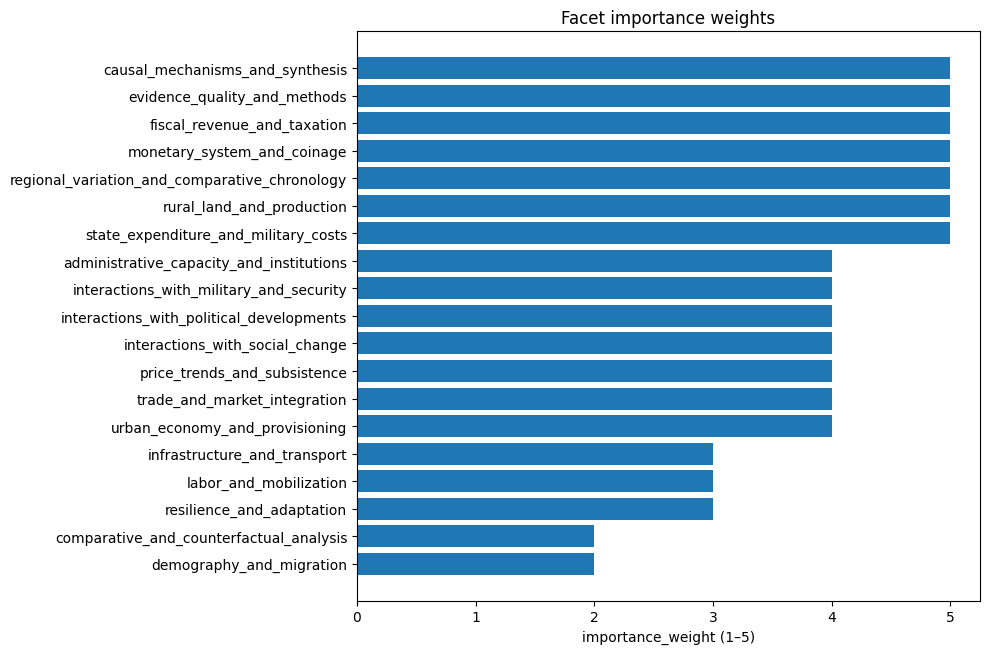

In [8]:
# Phase B.4 — Run the planner + inspect facets

try:
    import pandas as pd
except Exception:
    pd = None
    print("[WARN] pandas not available; facet table will be plain text. Install with: pip install pandas")

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None
    print("[WARN] matplotlib not available; facet plot will be skipped. Install with: pip install matplotlib")


import textwrap


def _print_paragraph(text: str, width: int = 100) -> None:
    s = str(text or "").strip()
    if not s:
        print("<empty>")
        return
    print(textwrap.fill(s, width=width))


def _join_terms(terms, *, max_terms: int = 14, max_chars: int = 220) -> str:
    arr = [str(t).strip() for t in (terms or []) if str(t).strip()]
    s = ", ".join(arr[:max_terms])
    if len(arr) > max_terms:
        s = s + f", …(+{len(arr) - max_terms})"
    if len(s) > max_chars:
        s = s[: max_chars - 1] + "…"
    return s




chapter_input = ChapterInput(
    chapter_title=chapter_title,
    chapter_spec_text=chapter_spec_text,
    pipeline_version=pipeline_version,
)

expected_run_id = chapter_input.compute_run_id()
if expected_run_id != run_ctx.run_id:
    print_section("Phase B.4 — Warning")
    print_kv(
        {
            "msg": "run_id mismatch; rebuilding Phase A context with current inputs",
            "expected_run_id": expected_run_id,
            "current_run_id": run_ctx.run_id,
        },
        key_width=16,
    )

    run_id = expected_run_id
    run_dir = cfg.runs_root / run_id

    artifacts = artifacts.model_copy(
        update={
            "query_plan_json": run_dir / "query_plan.json",
            "openalex_queries_json": run_dir / "openalex_queries.json",
            "semanticscholar_queries_json": run_dir / "semanticscholar_queries.json",
            "openalex_raw_jsonl": run_dir / "openalex_raw.jsonl",
            "semanticscholar_raw_jsonl": run_dir / "semanticscholar_raw.jsonl",
            "semanticscholar_recommendations_jsonl": run_dir / "semanticscholar_recommendations.jsonl",
            "candidates_normalized_jsonl": run_dir / "candidates_normalized.jsonl",
            "candidates_normalized_csv": run_dir / "candidates_normalized.csv",
            "embeddings_manifest_jsonl": run_dir / "embeddings_manifest.jsonl",
            "embeddings_manifest_csv": run_dir / "embeddings_manifest.csv",
            "embeddings_vectors_dir": run_dir / "embeddings_vectors",
            "rerank_results_jsonl": run_dir / "rerank_results.jsonl",
            "output_json": run_dir / "output.json",
            "logs_jsonl": run_dir / "logs.jsonl",
            "run_log": run_dir / "run.log",
            "metrics_json": run_dir / "metrics.json",
        }
    )

    run_ctx = RunContext(repo_root=REPO_ROOT, run_id=run_id, run_dir=run_dir, artifacts=artifacts)
    run_ctx.create_artifact_skeleton(overwrite=False)
    logger = setup_run_logger(run_ctx)


plan, meta = plan_queries_llm(
    chapter_input,
    config=cfg,
    run_ctx=run_ctx,
    force_rebuild=FORCE_REBUILD_QUERY_PLAN,
)

diag = meta.get("diagnostics") or diagnose_query_plan(plan)

print_section("Phase B.4 — Query Plan")
print_kv(
    {
        "cache_hit": meta.get("cache_hit"),
        "run_id": run_ctx.run_id,
        "run_dir": run_ctx.run_dir,
        "query_plan.json": run_ctx.artifacts.query_plan_json,
    },
    key_width=14,
)

print_section("Topic Summary (EN)")
_print_paragraph(plan.topic_summary_en)

print_section("Topic Summary (DE)")
_print_paragraph(plan.topic_summary_de)

# OpenAI usage + cost
print_section("OpenAI Usage / Cost")
if meta.get("cache_hit"):
    print("cache hit — no new tokens billed")
else:
    usage = meta.get("usage") or {}
    cost = meta.get("cost_estimate") or {}

    input_tokens = int(usage.get("input_tokens") or 0)
    cached_input_tokens = int(usage.get("cached_input_tokens") or 0)
    billable_input_tokens = max(input_tokens - min(cached_input_tokens, input_tokens), 0)

    print_kv(
        {
            "model_used": meta.get("model_used"),
            "latency_s": meta.get("latency_s"),
            "input_tokens": _fmt_int(input_tokens),
            "cached_input_tokens": _fmt_int(cached_input_tokens),
            "billable_input_tokens": _fmt_int(billable_input_tokens),
            "output_tokens": _fmt_int(int(usage.get("output_tokens") or 0)),
            "reasoning_tokens": _fmt_int(int(usage.get("reasoning_tokens") or 0)),
            "cost_usd": f"{float(cost.get('total_cost_usd') or 0.0):.6f}",
        },
        key_width=20,
    )

print_section("Facet Diagnostics")
print_kv(
    {
        "facet_count": diag.get("facet_count"),
        "issues": len(diag.get("issues") or []),
    },
    key_width=12,
)
if diag.get("issues"):
    print("\nIssues:")
    for x in diag["issues"]:
        print(f"- {x}")

rows = []
for f in plan.facets:
    rows.append(
        {
            "facet_id": f.facet_id,
            "weight": f.importance_weight,
            "facet_type": f.facet_type,
            "label_en": _truncate(f.facet_label_en, 80),
            "canon_en": len(f.canonical_terms.en),
            "canon_de": len(f.canonical_terms.de),
            "excl_en": len(f.exclusion_terms.en),
            "excl_de": len(f.exclusion_terms.de),
        }
    )

print_section("Facets")
if pd is not None:
    df = pd.DataFrame(rows).sort_values(["weight", "facet_id"], ascending=[False, True])
    display(df)
else:
    print_table(
        sorted(rows, key=lambda x: (-x["weight"], x["facet_id"])),
        columns=["facet_id", "weight", "facet_type", "label_en", "canon_en", "canon_de", "excl_en", "excl_de"],
        max_rows=200,
    )
print_section("Global Term Previews")
try:
    global_rows = [
        {
            "kind": "global_canonical_terms",
            "lang": "en",
            "n": len(plan.global_canonical_terms.en),
            "terms": _join_terms(plan.global_canonical_terms.en, max_terms=25, max_chars=260),
        },
        {
            "kind": "global_canonical_terms",
            "lang": "de",
            "n": len(plan.global_canonical_terms.de),
            "terms": _join_terms(plan.global_canonical_terms.de, max_terms=25, max_chars=260),
        },
        {
            "kind": "global_exclusions",
            "lang": "en",
            "n": len(plan.global_exclusions.en),
            "terms": _join_terms(plan.global_exclusions.en, max_terms=20, max_chars=260),
        },
        {
            "kind": "global_exclusions",
            "lang": "de",
            "n": len(plan.global_exclusions.de),
            "terms": _join_terms(plan.global_exclusions.de, max_terms=20, max_chars=260),
        },
    ]
    print_table(global_rows, columns=["kind", "lang", "n", "terms"], max_rows=20, max_col_width=260)
except Exception as e:
    print(f"[WARN] failed to print global term previews: {e}")


print_section("Facet Term Previews (Top facets)")
try:
    ordered_facets = sorted(
        plan.facets,
        key=lambda f: (-int(getattr(f, "importance_weight", 0) or 0), str(getattr(f, "facet_id", "") or "")),
    )
    preview_rows = []
    for f in ordered_facets[: min(12, len(ordered_facets))]:
        preview_rows.append(
            {
                "facet_id": f.facet_id,
                "weight": f.importance_weight,
                "canon_en": _join_terms(getattr(f.canonical_terms, "en", []) or [], max_terms=14, max_chars=220),
                "canon_de": _join_terms(getattr(f.canonical_terms, "de", []) or [], max_terms=14, max_chars=220),
                "excl_en": _join_terms(getattr(f.exclusion_terms, "en", []) or [], max_terms=10, max_chars=180),
                "excl_de": _join_terms(getattr(f.exclusion_terms, "de", []) or [], max_terms=10, max_chars=180),
            }
        )

    print_table(
        preview_rows,
        columns=["facet_id", "weight", "canon_en", "canon_de", "excl_en", "excl_de"],
        max_rows=50,
        max_col_width=220,
    )
except Exception as e:
    print(f"[WARN] failed to print facet term previews: {e}")



if plt is not None:
    plt.figure(figsize=(10, max(3, 0.35 * len(rows))))
    ordered = sorted(rows, key=lambda x: (-x["weight"], x["facet_id"]))
    ids = [r["facet_id"] for r in ordered]
    ws = [r["weight"] for r in ordered]
    plt.barh(ids, ws)
    plt.gca().invert_yaxis()
    plt.title("Facet importance weights")
    plt.xlabel("importance_weight (1–5)")
    plt.tight_layout()
    plt.show()


In [9]:
# Phase C.0 — Provider query builders (schemas + exact prompts embedded)

import json
import hashlib
from typing import Any, Dict, List, Literal, Optional, Tuple

from pydantic import BaseModel
from pydantic.config import ConfigDict


class OpenAlexQuery(BaseModel):
    model_config = ConfigDict(extra="forbid")

    intent: Literal["authority", "match"]
    language: Literal["en", "de"]
    query_string: str
    filters: str
    sort: Optional[str] = None
    per_page: int
    notes: str


class OpenAlexQueriesOutput(BaseModel):
    model_config = ConfigDict(extra="forbid")

    openalex_queries: List[OpenAlexQuery]


class S2BulkQuery(BaseModel):
    model_config = ConfigDict(extra="forbid")

    intent: Literal["authority", "match"]
    language: Literal["en", "de"]
    query_string: str
    notes: str


class S2BulkQueriesOutput(BaseModel):
    model_config = ConfigDict(extra="forbid")

    s2_bulk_queries: List[S2BulkQuery]


OPENALEX_QUERIES_JSON_SCHEMA: Dict[str, Any] = {
    "type": "object",
    "additionalProperties": False,
    "required": ["openalex_queries"],
    "properties": {
        "openalex_queries": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "required": ["intent", "language", "query_string", "filters", "sort", "per_page", "notes"],
                "properties": {
                    "intent": {"type": "string", "enum": ["authority", "match"]},
                    "language": {"type": "string", "enum": ["en", "de"]},
                    "query_string": {"type": "string"},
                    "filters": {"type": "string"},
                    "sort": {
                        "anyOf": [
                            {"type": "string", "enum": ["cited_by_count:desc", "relevance_score:desc"]},
                            {"type": "null"},
                        ]
                    },
                    "per_page": {"type": "integer", "minimum": 1, "maximum": 200},
                    "notes": {"type": "string"},
                },
            },
        }
    },
}

S2_BULK_QUERIES_JSON_SCHEMA: Dict[str, Any] = {
    "type": "object",
    "additionalProperties": False,
    "required": ["s2_bulk_queries"],
    "properties": {
        "s2_bulk_queries": {
            "type": "array",
            "items": {
                "type": "object",
                "additionalProperties": False,
                "required": ["intent", "language", "query_string", "notes"],
                "properties": {
                    "intent": {"type": "string", "enum": ["authority", "match"]},
                    "language": {"type": "string", "enum": ["en", "de"]},
                    "query_string": {"type": "string"},
                    "notes": {"type": "string"},
                },
            },
        }
    },
}


def _sha256_text(s: str) -> str:
    return hashlib.sha256((s or "").encode("utf-8")).hexdigest()


def _preview_prompt(name: str, text: str, *, max_lines: int = 14, max_len: int = 180) -> None:
    lines = (text or "").splitlines()
    rows = []
    for i, line in enumerate(lines[:max_lines], start=1):
        rows.append({"line": i, "text": _truncate(line, max_len)})

    print_section(name)
    print_kv({"lines": _fmt_int(len(lines)), "chars": _fmt_int(len(text or ""))}, key_width=10)
    if rows:
        print_table(rows, columns=["line", "text"], max_rows=max_lines, max_col_width=max_len)
    else:
        print("<empty>")

    if len(lines) > max_lines:
        print(f"... (+{_fmt_int(len(lines) - max_lines)} more lines)")


# Prompt 2 (OpenAlex) — embedded EXACTLY from the plan file
OPENALEX_SYSTEM_PROMPT = """You generate OpenAlex /works query strings and parameter objects. You must obey OpenAlex boolean rules:
- Use UPPERCASE AND/OR/NOT
- Parentheses and double-quotes are allowed
- Do NOT use wildcard/fuzzy characters (* ? ~). If present, remove them.
- Queries should work well for scientific retrieval in English and German.
Be deterministic.
"""
OPENALEX_USER_PROMPT_TEMPLATE = """INPUT_QUERY_PLAN_JSON:
{{query_plan_json}}

BUDGET:
max_queries = {{max_queries}}  # hard cap for OpenAlex queries
languages = ["en","de"]

GOALS:
Produce a list of query objects for OpenAlex /works that support two intents:
(A) AUTHORITY retrieval (high-impact core literature)
(B) MATCH retrieval (high topical fit, including niche)

Each query object must include:
- intent: "authority" or "match"
- language: "en" or "de"
- query_string: boolean query targeting title/abstract/fulltext search behavior
- filters: OpenAlex filter string (language, is_paratext false if used, publication_year ranges if used)
- sort: one of:
   * "cited_by_count:desc" for authority
   * "relevance_score:desc" (or omit sort) for match
- per_page: 200
- notes: brief reason (<=20 words)

DIVERSITY RULES:
- Always include:
  * 1 global core query EN + 1 global core query DE
  * facet-targeted queries for ALL facets with importance_weight >=4 (both EN+DE if possible)
  * 2–4 neighbor queries (EN+DE)
  * 2–4 methods/evaluation queries if applicable (EN+DE)
- Use exclusion terms with NOT where it prevents wrong senses.
- Do not exceed max_queries. If too many, prioritize weight 5 facets, then weight 4, then global/neighbor.

OUTPUT:
Return ONLY JSON:
{ "openalex_queries": [ ... ] }"""

# Prompt 3 (Semantic Scholar bulk search) — embedded EXACTLY from the plan file
S2_SYSTEM_PROMPT = """You generate Semantic Scholar Academic Graph "paper bulk search" query strings.
Use operators consistent with Semantic Scholar bulk search examples:
- OR: |
- REQUIRED: +term
- EXCLUDE: -term
- quotes for exact phrase
Match is against title and abstract.
Be deterministic.
"""
S2_USER_PROMPT_TEMPLATE = """INPUT_QUERY_PLAN_JSON:
{{query_plan_json}}

BUDGET:
max_queries = {{max_queries}}  # hard cap for Semantic Scholar queries
languages = ["en","de"]

GOALS:
Produce a list of bulk search query objects for two intents:
(A) AUTHORITY (high-impact, broad)
(B) MATCH (high precision + recall)

Each query object must include:
- intent: "authority" or "match"
- language: "en" or "de"
- query_string: use | + - and "phrases"
- notes: <=20 words why this query exists

DIVERSITY RULES:
- Always include global EN+DE.
- Cover all facets with weight>=4 (prioritize).
- Add 2–4 neighbor-topic queries (EN+DE).
- Use exclusions (-term) to prevent wrong sense where needed.
- Keep query_string length reasonable (avoid > 220 chars unless necessary).
- Do not exceed max_queries.

OUTPUT:
Return ONLY JSON:
{ "s2_bulk_queries": [ ... ] }"""


print_section("Phase C.0 — Prompts Loaded")
print_kv(
    {
        "prompt_source": "embedded in sources_two_lane.ipynb",
        "openalex_system_sha256": _sha256_text(OPENALEX_SYSTEM_PROMPT)[:16],
        "openalex_user_sha256": _sha256_text(OPENALEX_USER_PROMPT_TEMPLATE)[:16],
        "openalex_system_chars": _fmt_int(len(OPENALEX_SYSTEM_PROMPT)),
        "openalex_user_chars": _fmt_int(len(OPENALEX_USER_PROMPT_TEMPLATE)),
        "openalex_has_query_plan_json": "{{query_plan_json}}" in OPENALEX_USER_PROMPT_TEMPLATE,
        "openalex_has_max_queries": "{{max_queries}}" in OPENALEX_USER_PROMPT_TEMPLATE,
        "s2_system_sha256": _sha256_text(S2_SYSTEM_PROMPT)[:16],
        "s2_user_sha256": _sha256_text(S2_USER_PROMPT_TEMPLATE)[:16],
        "s2_system_chars": _fmt_int(len(S2_SYSTEM_PROMPT)),
        "s2_user_chars": _fmt_int(len(S2_USER_PROMPT_TEMPLATE)),
        "s2_has_query_plan_json": "{{query_plan_json}}" in S2_USER_PROMPT_TEMPLATE,
        "s2_has_max_queries": "{{max_queries}}" in S2_USER_PROMPT_TEMPLATE,
    },
    key_width=26,
)

print_section("Phase C.0 — Prompt Previews")
_preview_prompt("OpenAlex SYSTEM", OPENALEX_SYSTEM_PROMPT)
_preview_prompt("OpenAlex USER template", OPENALEX_USER_PROMPT_TEMPLATE)
_preview_prompt("S2 SYSTEM", S2_SYSTEM_PROMPT)
_preview_prompt("S2 USER template", S2_USER_PROMPT_TEMPLATE)


def render_openalex_user_prompt(*, query_plan_json: str, max_queries: int) -> str:
    s = OPENALEX_USER_PROMPT_TEMPLATE
    s = s.replace("{{query_plan_json}}", query_plan_json)
    s = s.replace("{{max_queries}}", str(int(max_queries)))
    return s


def render_s2_user_prompt(*, query_plan_json: str, max_queries: int) -> str:
    s = S2_USER_PROMPT_TEMPLATE
    s = s.replace("{{query_plan_json}}", query_plan_json)
    s = s.replace("{{max_queries}}", str(int(max_queries)))
    return s




Phase C.0 — Prompts Loaded
prompt_source              embedded in sources_two_lane.ipynb
openalex_system_sha256     f751788ce2cbfc72
openalex_user_sha256       c7877254ff6073a3
openalex_system_chars      341
openalex_user_chars        1,272
openalex_has_query_plan_json True
openalex_has_max_queries   True
s2_system_sha256           866966182b1b96a9
s2_user_sha256             3ede31f86b6ff591
s2_system_chars            273
s2_user_chars              823
s2_has_query_plan_json     True
s2_has_max_queries         True
Phase C.0 — Prompt Previews
OpenAlex SYSTEM
lines      6
chars      341
line | text                                                                                                   
-----+--------------------------------------------------------------------------------------------------------
1    | You generate OpenAlex /works query strings and parameter objects. You must obey OpenAlex boolean rules:
2    | - Use UPPERCASE AND/OR/NOT                                         

In [10]:
# Phase C.1 — Build and cache provider queries (OpenAlex + Semantic Scholar)

import traceback
from typing import Any, Dict, Tuple


def build_openalex_queries_llm(
    query_plan: QueryPlan,
    *,
    config: PipelineConfig,
    run_ctx: RunContext,
    force_rebuild: bool = False,
) -> Tuple[OpenAlexQueriesOutput, Dict[str, Any]]:
    stage = "phase_c_openalex_query_builder"
    cache_path = run_ctx.artifacts.openalex_queries_json

    if cache_path.exists() and not force_rebuild:
        try:
            cached_obj = read_json(cache_path)
            out = OpenAlexQueriesOutput.model_validate(cached_obj)
            meta = {
                "cache_hit": True,
                "usage": {
                    "input_tokens": 0,
                    "cached_input_tokens": 0,
                    "output_tokens": 0,
                    "reasoning_tokens": 0,
                },
                "cost_estimate": {"total_cost_usd": 0.0},
            }
            log_event(run_ctx, stage=stage, event="cache_hit", path=str(cache_path))
            return out, meta
        except Exception as e:
            err = str(e)
            write_json(
                run_ctx.run_dir / "openalex_queries.cache_invalid.json",
                {"ts": utc_now_iso(), "path": str(cache_path), "error": err},
            )
            log_event(run_ctx, stage=stage, event="cache_invalid", path=str(cache_path), error=err[:800])

    query_plan_json = json.dumps(query_plan.model_dump(), ensure_ascii=False, indent=2)
    user_prompt = render_openalex_user_prompt(
        query_plan_json=query_plan_json,
        max_queries=config.max_queries_per_provider,
    )

    with stage_timer(run_ctx, stage):
        try:
            obj, meta = openai_json_schema_call(
                api_key=config.openai_api_key or "",
                model=config.openai_model_planner,
                system_prompt=OPENALEX_SYSTEM_PROMPT,
                user_prompt=user_prompt,
                schema_name="openalex_queries",
                schema=OPENALEX_QUERIES_JSON_SCHEMA,
                reasoning_effort=config.openai_reasoning_effort,
                max_output_tokens=max(2000, int(getattr(config, "openai_max_output_tokens_planner", 8000) or 8000)),
                timeout_s=config.openai_timeout_s,
                debug_dir=run_ctx.run_dir,
                debug_prefix="openalex_queries",
            )
        except Exception as e:
            dbg = {
                "ts": utc_now_iso(),
                "stage": stage,
                "error": str(e),
                "traceback": traceback.format_exc(),
            }
            write_json(run_ctx.run_dir / "openalex_queries.error.json", dbg)
            log_event(run_ctx, stage=stage, event="openai_error", error=str(e))
            raise

    write_json(run_ctx.run_dir / "openalex_queries.raw_output.json", obj)
    write_json(run_ctx.run_dir / "openalex_queries.openai_meta.json", meta)

    out = OpenAlexQueriesOutput.model_validate(obj)

    # Normalize: enforce per_page=200 and hard-cap to budget.
    budget = int(config.max_queries_per_provider or 0) or 50
    fixed = 0
    normalized = []
    for q in out.openalex_queries[:budget]:
        if int(q.per_page or 0) != 200:
            fixed += 1
            q = q.model_copy(update={"per_page": 200})
        normalized.append(q)
    trimmed = max(len(out.openalex_queries) - budget, 0)
    out = OpenAlexQueriesOutput(openalex_queries=normalized)

    if fixed or trimmed:
        log_event(
            run_ctx,
            stage=stage,
            event="normalized",
            fixed_per_page=fixed,
            trimmed_to_budget=trimmed,
            budget=budget,
        )

    write_json(cache_path, out.model_dump())
    log_event(
        run_ctx,
        stage=stage,
        event="built",
        query_count=len(out.openalex_queries),
        path=str(cache_path),
    )

    meta = {**meta, "cache_hit": False}
    return out, meta


def build_s2_bulk_queries_llm(
    query_plan: QueryPlan,
    *,
    config: PipelineConfig,
    run_ctx: RunContext,
    force_rebuild: bool = False,
) -> Tuple[S2BulkQueriesOutput, Dict[str, Any]]:
    stage = "phase_c_s2_query_builder"
    cache_path = run_ctx.artifacts.semanticscholar_queries_json

    if cache_path.exists() and not force_rebuild:
        try:
            cached_obj = read_json(cache_path)
            out = S2BulkQueriesOutput.model_validate(cached_obj)
            meta = {
                "cache_hit": True,
                "usage": {
                    "input_tokens": 0,
                    "cached_input_tokens": 0,
                    "output_tokens": 0,
                    "reasoning_tokens": 0,
                },
                "cost_estimate": {"total_cost_usd": 0.0},
            }
            log_event(run_ctx, stage=stage, event="cache_hit", path=str(cache_path))
            return out, meta
        except Exception as e:
            err = str(e)
            write_json(
                run_ctx.run_dir / "s2_bulk_queries.cache_invalid.json",
                {"ts": utc_now_iso(), "path": str(cache_path), "error": err},
            )
            log_event(run_ctx, stage=stage, event="cache_invalid", path=str(cache_path), error=err[:800])

    query_plan_json = json.dumps(query_plan.model_dump(), ensure_ascii=False, indent=2)
    user_prompt = render_s2_user_prompt(
        query_plan_json=query_plan_json,
        max_queries=config.max_queries_per_provider,
    )

    with stage_timer(run_ctx, stage):
        try:
            obj, meta = openai_json_schema_call(
                api_key=config.openai_api_key or "",
                model=config.openai_model_planner,
                system_prompt=S2_SYSTEM_PROMPT,
                user_prompt=user_prompt,
                schema_name="s2_bulk_queries",
                schema=S2_BULK_QUERIES_JSON_SCHEMA,
                reasoning_effort=config.openai_reasoning_effort,
                max_output_tokens=max(1500, int(getattr(config, "openai_max_output_tokens_planner", 6000) or 6000)),
                timeout_s=config.openai_timeout_s,
                debug_dir=run_ctx.run_dir,
                debug_prefix="s2_bulk_queries",
            )
        except Exception as e:
            dbg = {
                "ts": utc_now_iso(),
                "stage": stage,
                "error": str(e),
                "traceback": traceback.format_exc(),
            }
            write_json(run_ctx.run_dir / "s2_bulk_queries.error.json", dbg)
            log_event(run_ctx, stage=stage, event="openai_error", error=str(e))
            raise

    write_json(run_ctx.run_dir / "s2_bulk_queries.raw_output.json", obj)
    write_json(run_ctx.run_dir / "s2_bulk_queries.openai_meta.json", meta)

    out = S2BulkQueriesOutput.model_validate(obj)

    # Normalize: hard-cap to budget.
    budget = int(config.max_queries_per_provider or 0) or 50
    trimmed = max(len(out.s2_bulk_queries) - budget, 0)
    out = S2BulkQueriesOutput(s2_bulk_queries=out.s2_bulk_queries[:budget])

    if trimmed:
        log_event(
            run_ctx,
            stage=stage,
            event="normalized",
            trimmed_to_budget=trimmed,
            budget=budget,
        )

    write_json(cache_path, out.model_dump())
    log_event(
        run_ctx,
        stage=stage,
        event="built",
        query_count=len(out.s2_bulk_queries),
        path=str(cache_path),
    )

    meta = {**meta, "cache_hit": False}
    return out, meta


openalex_out, openalex_meta = build_openalex_queries_llm(
    plan,
    config=cfg,
    run_ctx=run_ctx,
    force_rebuild=FORCE_REBUILD_PROVIDER_QUERIES,
)

s2_out, s2_meta = build_s2_bulk_queries_llm(
    plan,
    config=cfg,
    run_ctx=run_ctx,
    force_rebuild=FORCE_REBUILD_PROVIDER_QUERIES,
)

print_section("Phase C.1 — Provider Queries Built")
print_kv(
    {
        "run_id": run_ctx.run_id,
        "run_dir": run_ctx.run_dir,
        "openalex_queries_json": run_ctx.artifacts.openalex_queries_json,
        "s2_queries_json": run_ctx.artifacts.semanticscholar_queries_json,
        "openalex_cache_hit": openalex_meta.get("cache_hit"),
        "s2_cache_hit": s2_meta.get("cache_hit"),
        "openalex_query_count": len(openalex_out.openalex_queries),
        "s2_query_count": len(s2_out.s2_bulk_queries),
    },
    key_width=22,
)


def _print_usage_cost(meta: Dict[str, Any], *, label: str) -> None:
    print_section(f"OpenAI Usage / Cost — {label}")
    if meta.get("cache_hit"):
        print("cache hit — no new tokens billed")
        return

    usage = meta.get("usage") or {}
    cost = meta.get("cost_estimate") or {}

    input_tokens = int(usage.get("input_tokens") or 0)
    cached_input_tokens = int(usage.get("cached_input_tokens") or 0)
    billable_input_tokens = max(input_tokens - min(cached_input_tokens, input_tokens), 0)

    print_kv(
        {
            "model_used": meta.get("model_used"),
            "latency_s": meta.get("latency_s"),
            "input_tokens": _fmt_int(input_tokens),
            "cached_input_tokens": _fmt_int(cached_input_tokens),
            "billable_input_tokens": _fmt_int(billable_input_tokens),
            "output_tokens": _fmt_int(int(usage.get("output_tokens") or 0)),
            "reasoning_tokens": _fmt_int(int(usage.get("reasoning_tokens") or 0)),
            "cost_usd": f"{float(cost.get('total_cost_usd') or 0.0):.6f}",
        },
        key_width=20,
    )


_print_usage_cost(openalex_meta, label="OpenAlex builder")
_print_usage_cost(s2_meta, label="S2 bulk builder")




2026-02-12 00:45:32,825 | INFO | {"stage": "phase_c_openalex_query_builder", "event": "cache_hit", "path": "E:\\Datein\\Coding\\instantpaper\\sources-v2\\runs\\d5a67f10a618dec647502773\\openalex_queries.json"}
2026-02-12 00:45:32,827 | INFO | {"stage": "phase_c_s2_query_builder", "event": "cache_hit", "path": "E:\\Datein\\Coding\\instantpaper\\sources-v2\\runs\\d5a67f10a618dec647502773\\semanticscholar_queries.json"}
Phase C.1 — Provider Queries Built
run_id                 d5a67f10a618dec647502773
run_dir                <projektverzeichnis>\sources-v2\runs\d5a67f10a618dec647502773
openalex_queries_json  <projektverzeichnis>\sources-v2\runs\d5a67f10a618dec647502773\openalex_queries.json
s2_queries_json        <projektverzeichnis>\sources-v2\runs\d5a67f10a618dec647502773\semanticscholar_queries.json
openalex_cache_hit     True
s2_cache_hit           True
openalex_query_count   40
s2_query_count         50
OpenAI Usage / Cost — OpenAlex builder
cache hit — no new tokens billed
OpenAI Usa

Phase C.2 — OpenAlex Queries
count              40
max_queries_budget 50
issues             1
i  | intent    | lang | chars | sort                 | per_page | filters                                       | query                                                                                                                    | notes                                                     | issues             
---+-----------+------+-------+----------------------+----------+-----------------------------------------------+--------------------------------------------------------------------------------------------------------------------------+-----------------------------------------------------------+--------------------
1  | authority | en   | 142   | cited_by_count:desc  | 200      | is_paratext:false;display_name.search_lang:en | ("Late Antiquity" OR "Western Roman Empire" OR "Late Roman") AND (economy OR fiscal OR taxation OR coinage OR "land ten… | High-impact core literature on Late

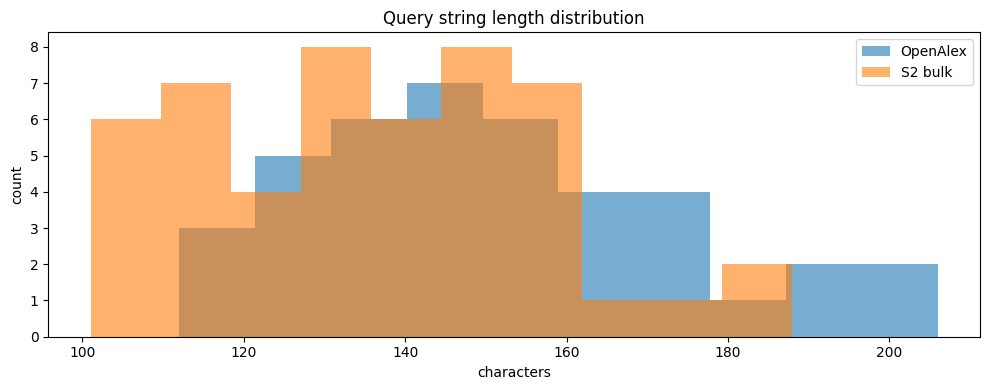

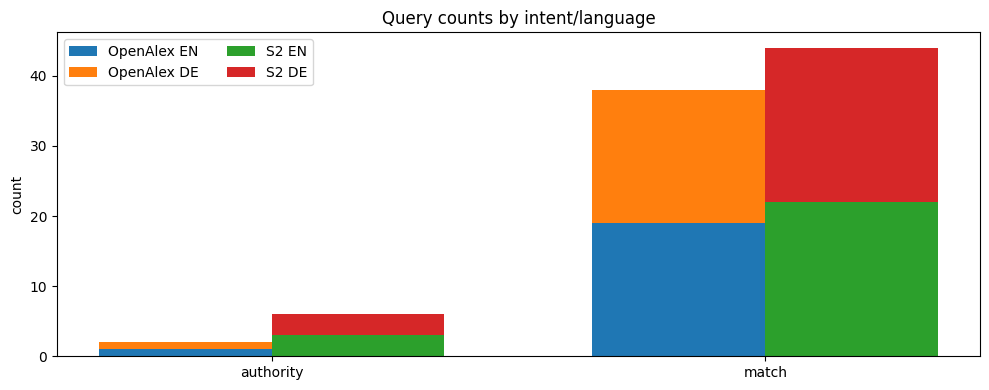

In [11]:
# Phase C.2 — Inspect provider queries (tables + metrics + plots)

import re
try:
    import pandas as pd
except Exception:
    pd = None

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None


def _contains_any(s: str, terms: List[str]) -> bool:
    hay = (s or "").lower()
    for t in terms or []:
        tt = (t or "").strip().lower()
        if not tt:
            continue
        if tt in hay:
            return True
    return False


def _openalex_issues(q: OpenAlexQuery) -> List[str]:
    issues = []
    qs = q.query_string or ""

    if any(ch in qs for ch in ["*", "?", "~"]):
        issues.append("forbidden_wildcards")

    # operators should be uppercase when used
    if re.search(r"and|or|not", qs):
        issues.append("lowercase_boolean_operator")

    if int(q.per_page or 0) != 200:
        issues.append("per_page_not_200")

    if q.intent == "authority":
        if (q.sort or "").strip() != "cited_by_count:desc":
            issues.append("authority_sort_not_cited_by_count_desc")

    return issues


def _s2_issues(q: S2BulkQuery) -> List[str]:
    issues = []
    qs = q.query_string or ""
    if len(qs) > 220:
        issues.append("query_too_long")
    return issues


openalex_rows = []
for i, q in enumerate(openalex_out.openalex_queries, start=1):
    issues = _openalex_issues(q)
    openalex_rows.append(
        {
            "i": i,
            "intent": q.intent,
            "lang": q.language,
            "chars": len(q.query_string or ""),
            "sort": (q.sort or "").strip() or "<none>",
            "per_page": q.per_page,
            "filters": _truncate(q.filters, 80),
            "query": _truncate(q.query_string, 120),
            "notes": _truncate(q.notes, 80),
            "issues": ",".join(issues) if issues else "",
        }
    )

s2_rows = []
for i, q in enumerate(s2_out.s2_bulk_queries, start=1):
    issues = _s2_issues(q)
    s2_rows.append(
        {
            "i": i,
            "intent": q.intent,
            "lang": q.language,
            "chars": len(q.query_string or ""),
            "query": _truncate(q.query_string, 140),
            "notes": _truncate(q.notes, 90),
            "issues": ",".join(issues) if issues else "",
        }
    )

print_section("Phase C.2 — OpenAlex Queries")
print_kv(
    {
        "count": len(openalex_rows),
        "max_queries_budget": cfg.max_queries_per_provider,
        "issues": sum(1 for r in openalex_rows if r["issues"]),
    },
    key_width=18,
)
print_table(
    openalex_rows,
    columns=["i", "intent", "lang", "chars", "sort", "per_page", "filters", "query", "notes", "issues"],
    max_rows=200,
    max_col_width=120,
)

print_section("Phase C.2 — S2 Bulk Queries")
print_kv(
    {
        "count": len(s2_rows),
        "max_queries_budget": cfg.max_queries_per_provider,
        "issues": sum(1 for r in s2_rows if r["issues"]),
    },
    key_width=18,
)
print_table(
    s2_rows,
    columns=["i", "intent", "lang", "chars", "query", "notes", "issues"],
    max_rows=200,
    max_col_width=140,
)


# Facet coverage heuristic: how many queries contain at least one canonical term.
coverage_rows = []
for f in plan.facets:
    terms = list((f.canonical_terms.en or []) + (f.canonical_terms.de or []))
    oa_hits = sum(1 for q in openalex_out.openalex_queries if _contains_any(q.query_string, terms))
    s2_hits = sum(1 for q in s2_out.s2_bulk_queries if _contains_any(q.query_string, terms))
    coverage_rows.append(
        {
            "facet_id": f.facet_id,
            "weight": f.importance_weight,
            "label_en": _truncate(f.facet_label_en, 70),
            "openalex_hits": oa_hits,
            "s2_hits": s2_hits,
        }
    )

coverage_rows_sorted = sorted(coverage_rows, key=lambda r: (-int(r["weight"] or 0), r["facet_id"]))



def _join_terms(terms: List[str], *, max_terms: int = 12, max_chars: int = 220) -> str:
    arr = [str(t).strip() for t in (terms or []) if str(t).strip()]
    s = ", ".join(arr[:max_terms])
    if len(arr) > max_terms:
        s = s + f", …(+{len(arr) - max_terms})"
    if len(s) > max_chars:
        s = s[: max_chars - 1] + "…"
    return s


print_section("Facet Term Preview (weight>=4)")
facet_term_rows = []
for f in sorted(plan.facets, key=lambda x: (-int(x.importance_weight or 0), str(x.facet_id or ""))):
    if int(f.importance_weight or 0) < 4:
        continue
    facet_term_rows.append(
        {
            "facet_id": f.facet_id,
            "weight": f.importance_weight,
            "canon_en": _join_terms(getattr(f.canonical_terms, "en", []) or [], max_terms=14, max_chars=260),
            "canon_de": _join_terms(getattr(f.canonical_terms, "de", []) or [], max_terms=14, max_chars=260),
            "excl_en": _join_terms(getattr(f.exclusion_terms, "en", []) or [], max_terms=10, max_chars=200),
            "excl_de": _join_terms(getattr(f.exclusion_terms, "de", []) or [], max_terms=10, max_chars=200),
        }
    )

print_table(
    facet_term_rows,
    columns=["facet_id", "weight", "canon_en", "canon_de", "excl_en", "excl_de"],
    max_rows=200,
    max_col_width=260,
)

print_section("Facet Coverage (heuristic)")
print_table(
    coverage_rows_sorted,
    columns=["facet_id", "weight", "openalex_hits", "s2_hits", "label_en"],
    max_rows=200,
    max_col_width=80,
)

missing_important = [r for r in coverage_rows_sorted if int(r["weight"] or 0) >= 4 and (r["openalex_hits"] + r["s2_hits"]) == 0]
if missing_important:
    print("\nWeight>=4 facets with 0 heuristic hits:")

    for r in missing_important:
        print(f"- {r['facet_id']} (w={r['weight']})")


# Plots
if plt is not None:
    # Query length distribution
    plt.figure(figsize=(10, 4))
    oa_lens = [len(q.query_string or "") for q in openalex_out.openalex_queries]
    s2_lens = [len(q.query_string or "") for q in s2_out.s2_bulk_queries]
    bins = max(10, min(40, int((max(oa_lens + s2_lens + [1]) / 20))))
    plt.hist(oa_lens, bins=bins, alpha=0.6, label="OpenAlex")
    plt.hist(s2_lens, bins=bins, alpha=0.6, label="S2 bulk")
    plt.title("Query string length distribution")
    plt.xlabel("characters")
    plt.ylabel("count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Counts by intent/language
    def _count(rows, intent, lang):
        return sum(1 for r in rows if r.get("intent") == intent and r.get("lang") == lang)

    intents = ["authority", "match"]
    langs = ["en", "de"]

    oa_counts = [[_count(openalex_rows, i, l) for l in langs] for i in intents]
    s2_counts = [[_count(s2_rows, i, l) for l in langs] for i in intents]

    x = range(len(intents))
    w = 0.35

    plt.figure(figsize=(10, 4))
    plt.bar([xx - w / 2 for xx in x], [c[0] for c in oa_counts], width=w, label="OpenAlex EN")
    plt.bar([xx - w / 2 for xx in x], [c[1] for c in oa_counts], width=w, bottom=[c[0] for c in oa_counts], label="OpenAlex DE")

    plt.bar([xx + w / 2 for xx in x], [c[0] for c in s2_counts], width=w, label="S2 EN")
    plt.bar([xx + w / 2 for xx in x], [c[1] for c in s2_counts], width=w, bottom=[c[0] for c in s2_counts], label="S2 DE")

    plt.xticks(list(x), intents)
    plt.title("Query counts by intent/language")
    plt.ylabel("count")
    plt.legend(ncols=2)
    plt.tight_layout()
    plt.show()